In [84]:
!pip install --force-reinstall numpy scipy scikit-learn seaborn
!pip install cleanlab[datalab]

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 104.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 70.6 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 111.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 108.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 114.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 129.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 199.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 128.9 MB/s eta 0:00:00
    tinycss2 (>=1.1.0<1.2) ; extra == 'css'
             ~~~~~~~~^
    torch (>=1.10.0+cu113<1.11.0)
           ~~~~~~~~^
  Attempting uninstall: pytz
    Found existing installation: pytz 2022.1
    Uninstalling pytz-2022.1:
      Successfully uninstalled pytz-2022.1
  Attempting unin

# Initialization


In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import os
import torch


import seaborn as sns
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import confusion_matrix
from cleanlab import Datalab

SEED = 1994
np.random.seed(SEED)
random.seed(SEED)



/opt/conda/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
LABEL_NAMES = {
    0: "Sedentary",
    1: "Standing",
    2: "Stepping",
    3: "Lying",
    4: "Seated_Transport",
    5: "Transition-active",
    6: "Transition-mixed",
}

split = "train"

## Import Data

cleanlab_df data

In [ ]:
data_path = "/niddk-data-central/mae_hr/rise_moca_4AP_20s_transition"
cleanlab_df_org = pd.read_csv(os.path.join(data_path, f"pred_gt_df/cleanlab_df_{split}.csv"))
cleanlab_df = cleanlab_df_org.reset_index()
safe_df = cleanlab_df[cleanlab_df['is_label_issue'] == 0]
flagged_df = cleanlab_df[cleanlab_df['is_label_issue'] == 1]


: 

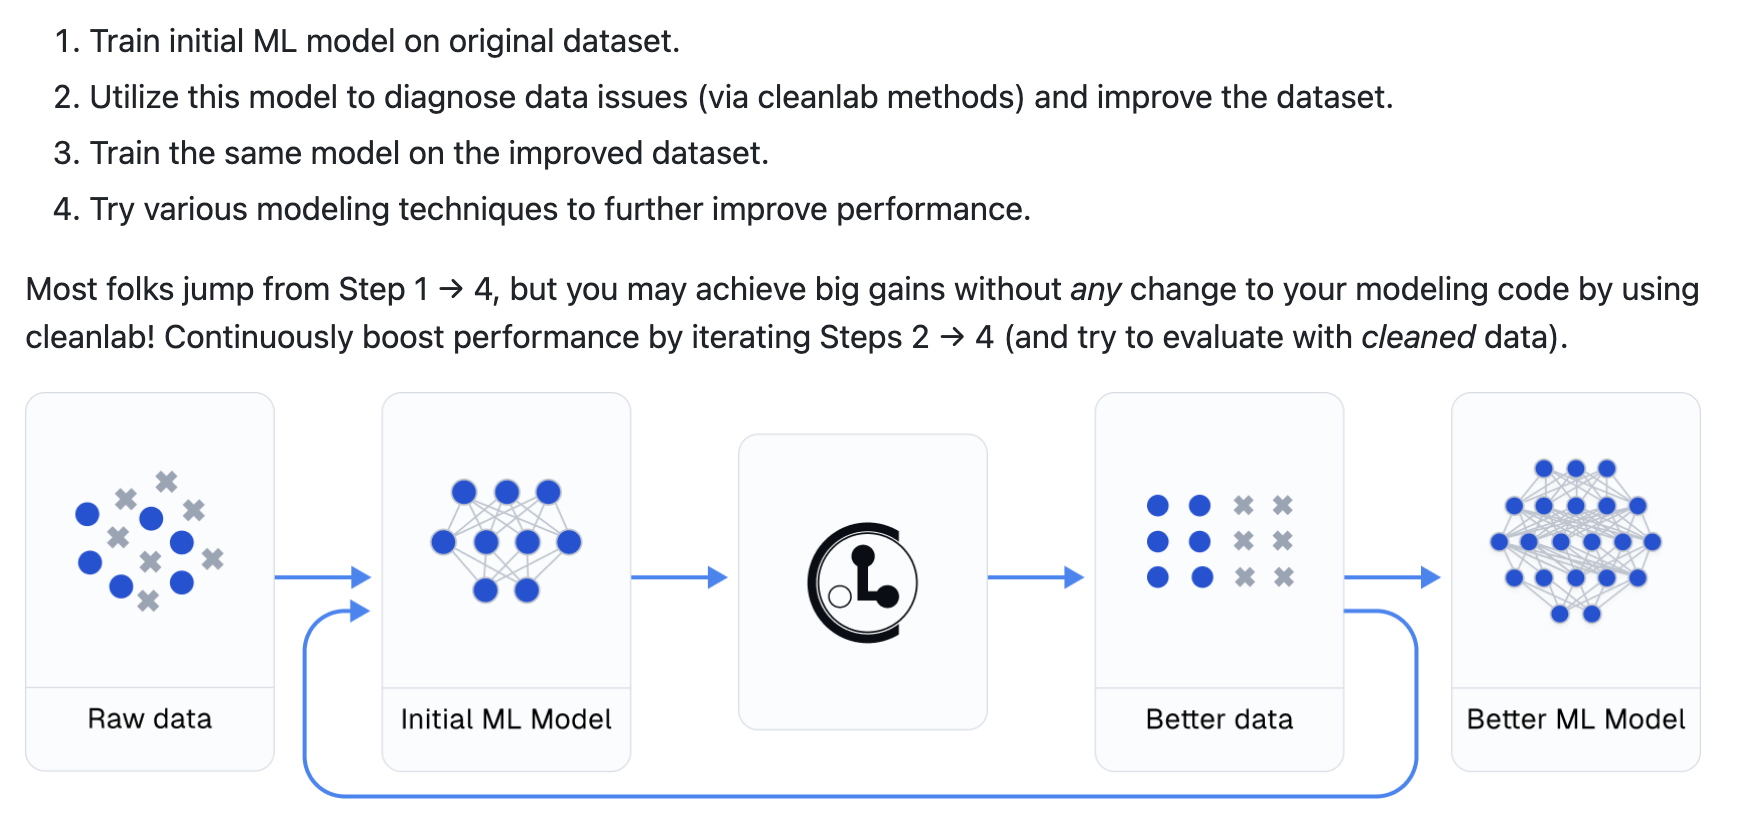

Notes

1. First application to 20s data (4s takes longer time--currently underway)
2. I think generally using the statistical features instead of the raw data for additional verification is good -- the prediction from cleanlab model generally agrees with ours, but it is not our model, so it's not "picking and choosing" the sample as we see fit.


# Investigating cleanlab report

Basic label distribution

Percentabge of filtered data = 18.34%


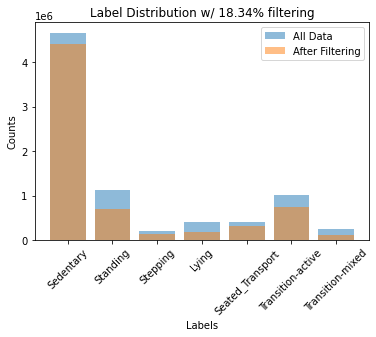

In [ ]:
# Bar plot before and after filtering
unique_all, counts_all = np.unique(cleanlab_df_org['given_label'].values, return_counts=True)
unique_safe, counts_safe = np.unique(safe_df['given_label'].values, return_counts=True)
plt.bar(unique_all, counts_all, alpha=0.5, label='All Data')
plt.bar(unique_safe, counts_safe, alpha=0.5, label='After Filtering')
plt.xlabel("Labels")
plt.ylabel("Counts")
plt.legend()
plt.xticks(ticks=list(LABEL_NAMES.keys()), labels=[LABEL_NAMES[i] for i in LABEL_NAMES.keys()], rotation=45)
plt.title(f"Label Distribution w/ {len(flagged_df) / len(cleanlab_df) * 100:.2f}% filtering")

print(f"Percentabge of filtered data = {len(flagged_df) / len(cleanlab_df) * 100:.2f}%")

In [6]:
# Per-class breakdown
print("Label issues per class:")
for cls, name in LABEL_NAMES.items():
    in_class  = cleanlab_df[cleanlab_df["given_label_chr"] == name]
    n_flagged = in_class["is_label_issue"].sum()
    n_total   = len(in_class)
    pct = 100 * n_flagged / n_total if n_total > 0 else 0
    print(f"  {cls}  {name:>20s}:  {n_flagged:>4} / {n_total}  ({pct:.1f}%)")

Label issues per class:
  0             Sedentary:  240883 / 4662037  (5.2%)
  1              Standing:  428621 / 1126053  (38.1%)
  2              Stepping:  78000 / 202850  (38.5%)
  3                 Lying:  226591 / 400421  (56.6%)
  4      Seated_Transport:  104847 / 407986  (25.7%)
  5     Transition-active:  268986 / 1015037  (26.5%)
  6      Transition-mixed:  128765 / 236476  (54.5%)


In [17]:
cleanlab_df


,index,is_label_issue,label_score,given_label,predicted_label,MoCA_pred,given_label_chr,MoCA_pred_chr,predicted_label_chr
0,0,False,0.234649,1,0,6,Standing,Transition-mixed,Sedentary
1,1,False,0.377294,1,0,0,Standing,Sedentary,Sedentary
2,2,False,0.261959,6,5,0,Transition-mixed,Sedentary,Transition-active
3,3,True,0.151123,1,0,0,Standing,Sedentary,Sedentary
4,4,False,0.200889,1,0,0,Standing,Sedentary,Sedentary
...,...,...,...,...,...,...,...,...,...
8050855,8050855,True,0.255547,5,1,5,Transition-active,Transition-active,Standing
8050856,8050856,True,0.317029,1,5,5,Standing,Transition-active,Transition-active
8050857,8050857,True,0.164037,5,1,1,Transition-active,Standing,Standing
8050858,8050858,False,0.536866,5,5,6,Transition-active,Transition-mixed,Transition-active


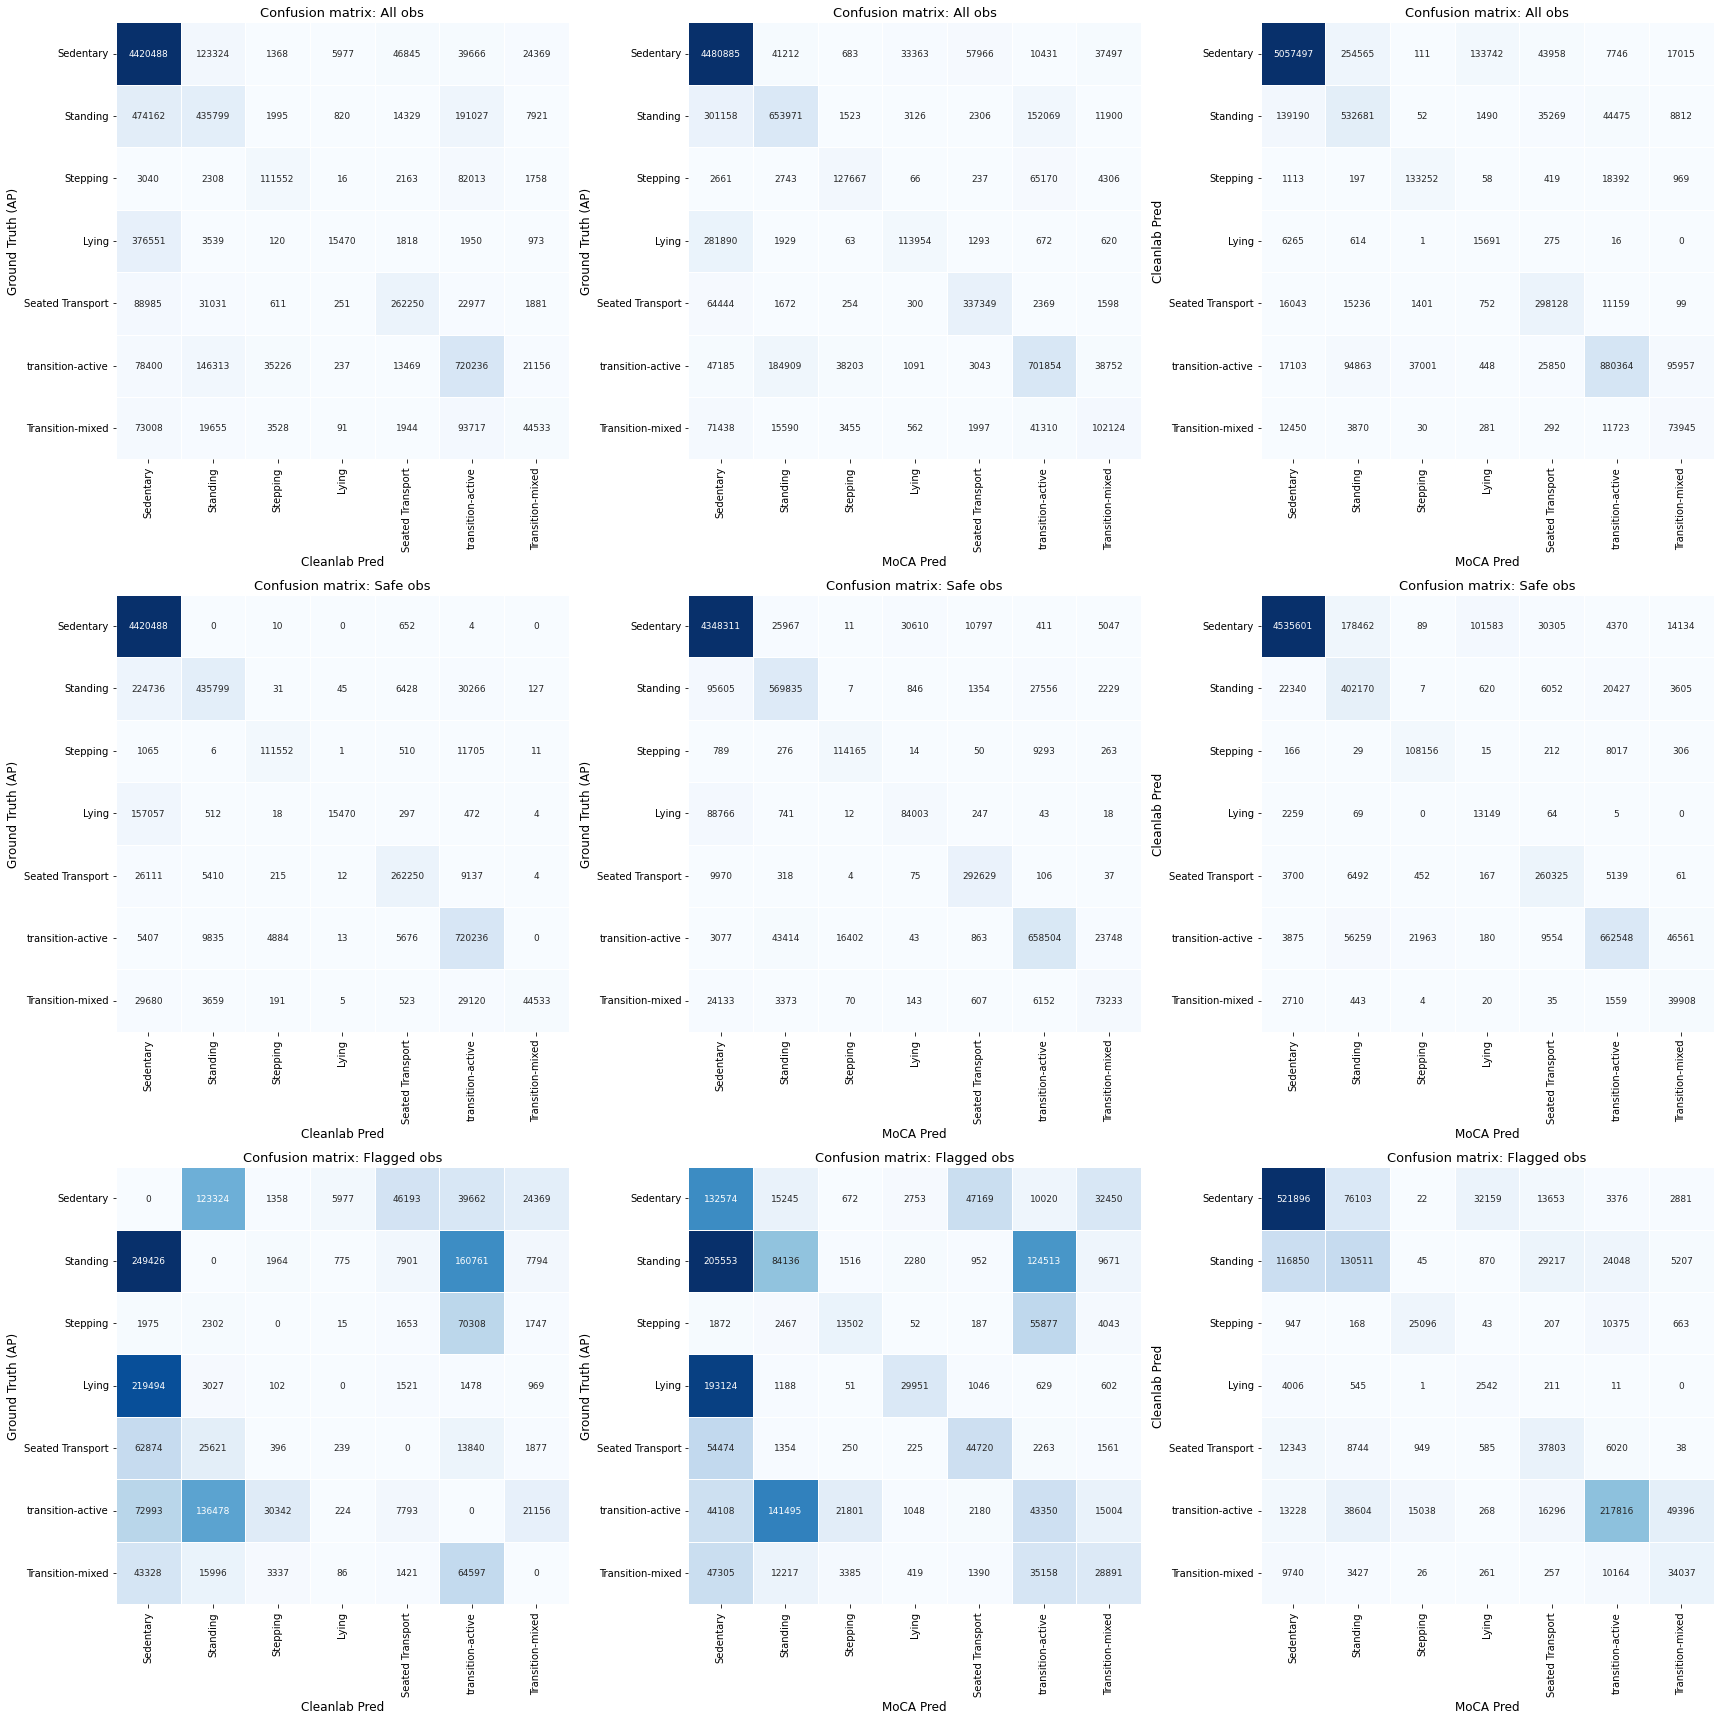

In [ ]:
# three-way confusion matrix
labels = ["Sedentary", "Standing", "Stepping", "Lying", "Seated Transport", "transition-active", "Transition-mixed"]


configs = [
    # (df, xlabel, ylabel, title)
    (cleanlab_df, "predicted_label", "given_label",      "Cleanlab Pred",  "Ground Truth (AP)", "All obs"),
    (cleanlab_df, "MoCA_pred",       "given_label",      "MoCA Pred",      "Ground Truth (AP)", "All obs"),
    (cleanlab_df, "MoCA_pred",       "predicted_label",  "MoCA Pred",      "Cleanlab Pred",     "All obs"),

    (safe_df,     "predicted_label", "given_label",      "Cleanlab Pred",  "Ground Truth (AP)", "Safe obs"),
    (safe_df,     "MoCA_pred",       "given_label",      "MoCA Pred",      "Ground Truth (AP)", "Safe obs"),
    (safe_df,     "MoCA_pred",       "predicted_label",  "MoCA Pred",      "Cleanlab Pred",     "Safe obs"),

    (flagged_df,  "predicted_label", "given_label",      "Cleanlab Pred",  "Ground Truth (AP)", "Flagged obs"),
    (flagged_df,  "MoCA_pred",       "given_label",      "MoCA Pred",      "Ground Truth (AP)", "Flagged obs"),
    (flagged_df,  "MoCA_pred",       "predicted_label",  "MoCA Pred",      "Cleanlab Pred",     "Flagged obs"),
]

fig, axes = plt.subplots(3, 3, figsize=(24, 24))

for ax, (df, col_x, col_y, xlabel, ylabel, subtitle) in zip(axes.flat, configs):
    cm = confusion_matrix(df[col_y], df[col_x])
    sns.heatmap(cm, annot=True, cmap='Blues', fmt='d',
                xticklabels=labels, yticklabels=labels,
                cbar=False, linewidth=.5, annot_kws={"fontsize": 9}, ax=ax)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f"Confusion matrix: {subtitle}", fontsize=13)

plt.tight_layout()
plt.show()

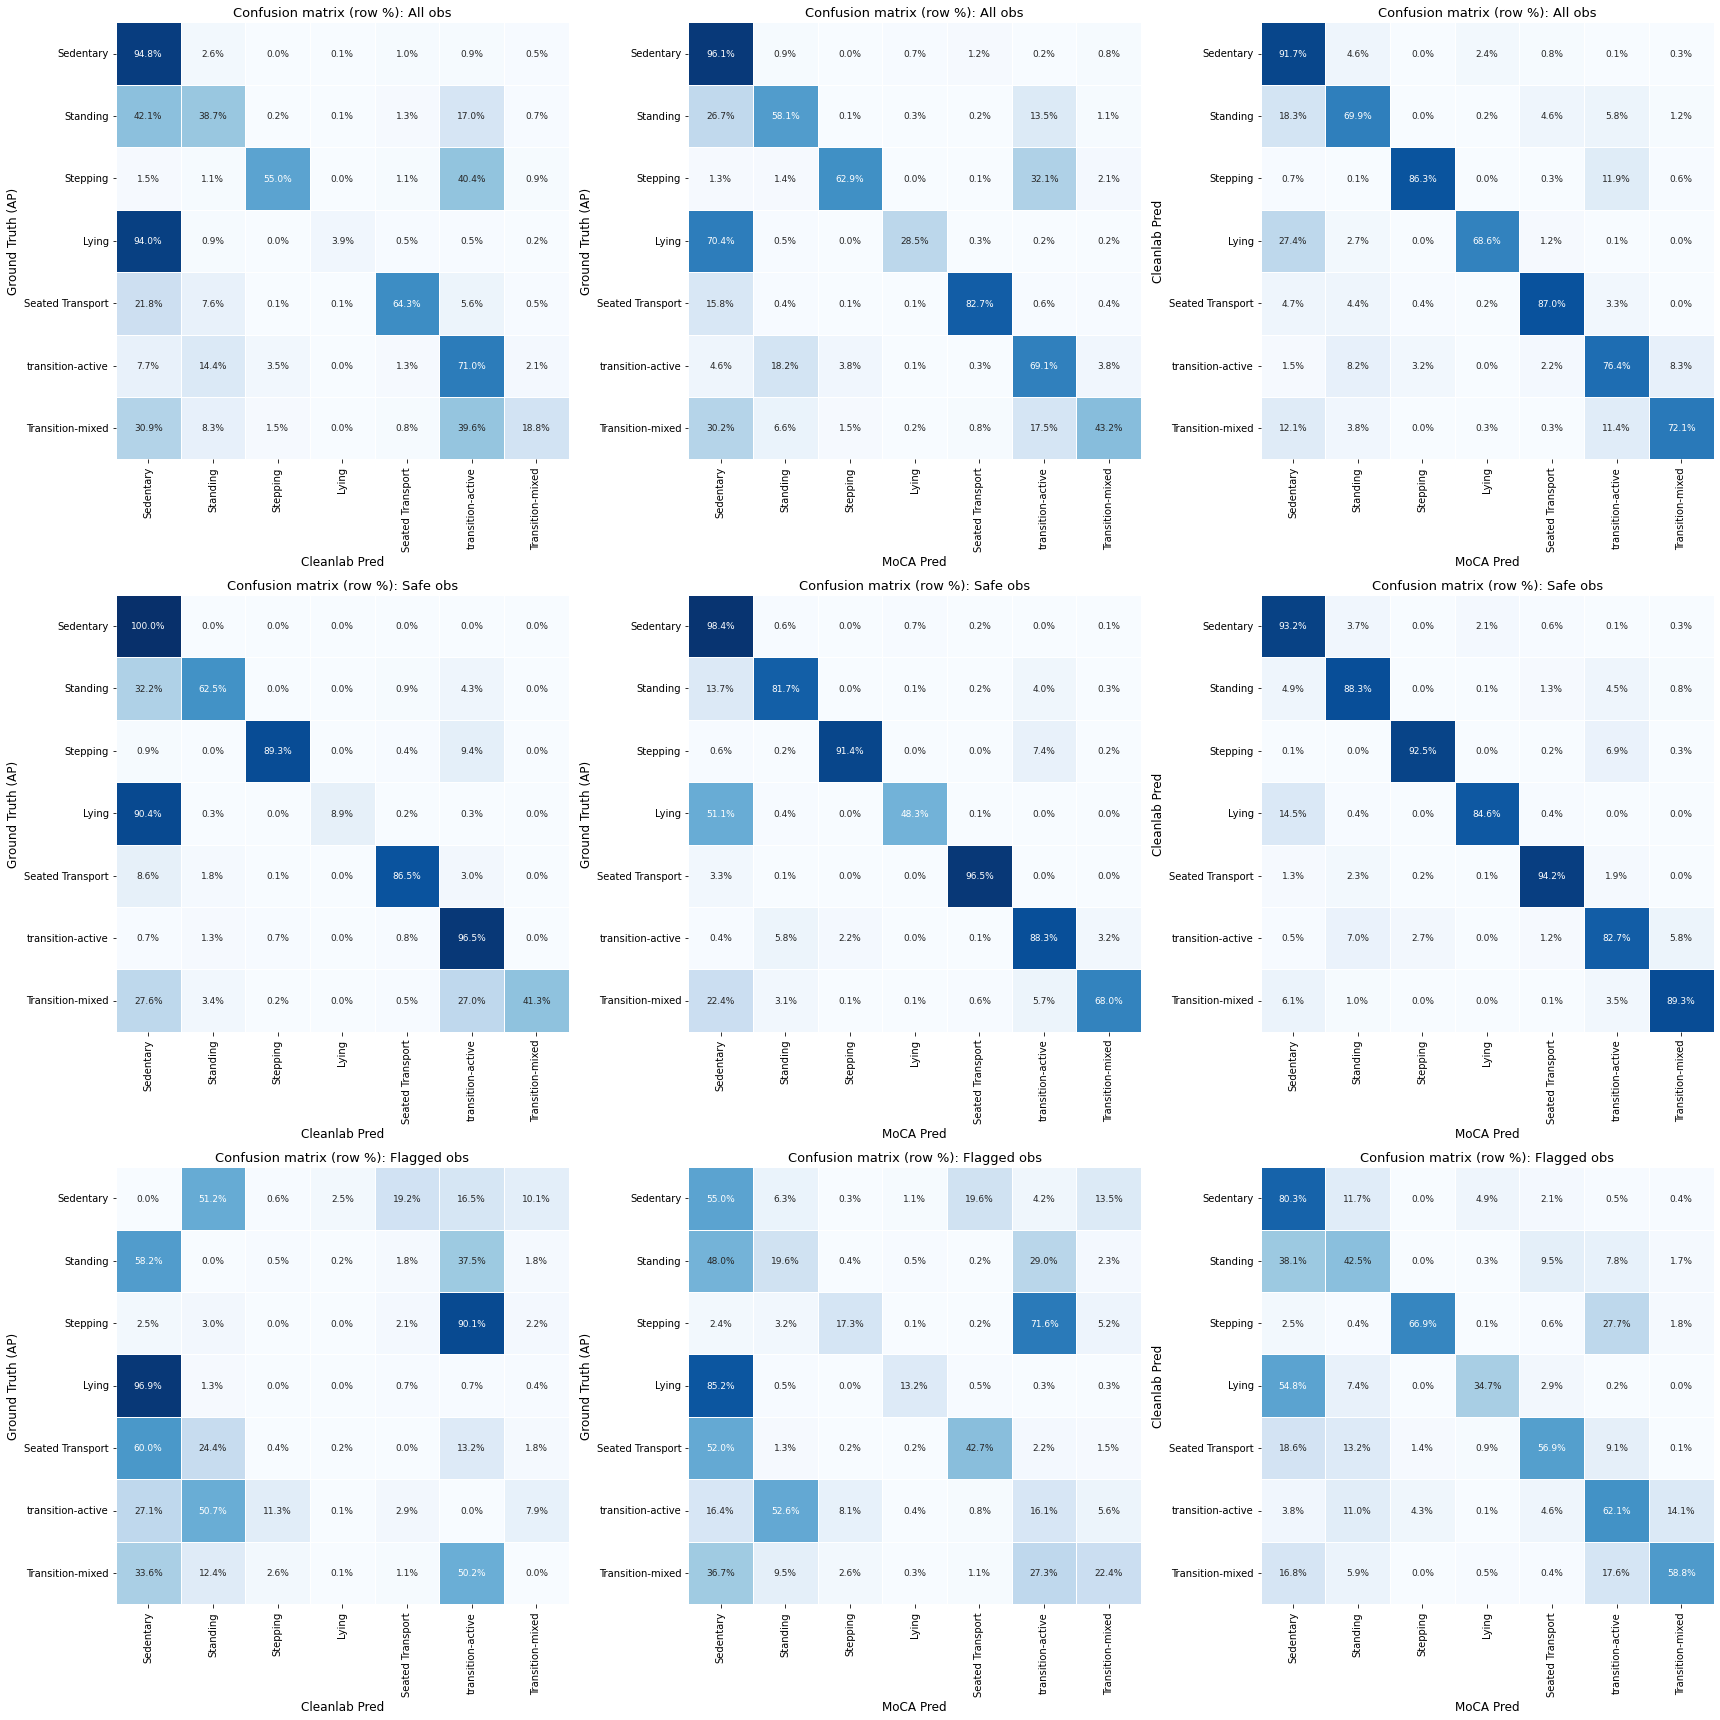

In [26]:
# three-way confusion matrix (row percentages)
labels = ["Sedentary", "Standing", "Stepping", "Lying", "Seated Transport", "transition-active", "Transition-mixed"]

configs = [
    (cleanlab_df, "predicted_label", "given_label",     "Cleanlab Pred",  "Ground Truth (AP)", "All obs"),
    (cleanlab_df, "MoCA_pred",       "given_label",     "MoCA Pred",      "Ground Truth (AP)", "All obs"),
    (cleanlab_df, "MoCA_pred",       "predicted_label", "MoCA Pred",      "Cleanlab Pred",     "All obs"),

    (safe_df,     "predicted_label", "given_label",     "Cleanlab Pred",  "Ground Truth (AP)", "Safe obs"),
    (safe_df,     "MoCA_pred",       "given_label",     "MoCA Pred",      "Ground Truth (AP)", "Safe obs"),
    (safe_df,     "MoCA_pred",       "predicted_label", "MoCA Pred",      "Cleanlab Pred",     "Safe obs"),

    (flagged_df,  "predicted_label", "given_label",     "Cleanlab Pred",  "Ground Truth (AP)", "Flagged obs"),
    (flagged_df,  "MoCA_pred",       "given_label",     "MoCA Pred",      "Ground Truth (AP)", "Flagged obs"),
    (flagged_df,  "MoCA_pred",       "predicted_label", "MoCA Pred",      "Cleanlab Pred",     "Flagged obs"),
]

fig, axes = plt.subplots(3, 3, figsize=(24, 24))

for ax, (df, col_x, col_y, xlabel, ylabel, subtitle) in zip(axes.flat, configs):
    cm = confusion_matrix(df[col_y], df[col_x])
    
    # Normalize by row (true label), replace NaN from empty rows with 0
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    cm_pct = np.nan_to_num(cm_pct)
    
    annot = np.array([[f"{v:.1f}%" for v in row] for row in cm_pct])

    sns.heatmap(cm_pct, annot=annot, cmap='Blues', fmt='s',
                xticklabels=labels, yticklabels=labels,
                cbar=False, linewidth=.5, annot_kws={"fontsize": 9}, ax=ax,
                vmin=0, vmax=100)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f"Confusion matrix (row %): {subtitle}", fontsize=13)

plt.tight_layout()
plt.show()

In [75]:
# Most common mislabelling transitions
transitions = Counter(zip(cleanlab_df["given_label_chr"], cleanlab_df["predicted_label_chr"]))
print("Top mis-label transitions (given  predicted):")
for (g, s), cnt in sorted(transitions.items(), key=lambda x: -x[1])[:10]:
    print(f"  {g}    {s}: {cnt}")


Top mis-label transitions (given  predicted):
  Sedentary    Sedentary: 4420488
  Transition-active    Transition-active: 720236
  Standing    Sedentary: 474162
  Standing    Standing: 435799
  Lying    Sedentary: 376551
  Seated_Transport    Seated_Transport: 262250
  Standing    Transition-active: 191027
  Transition-active    Standing: 146313
  Sedentary    Standing: 123324
  Stepping    Stepping: 111552


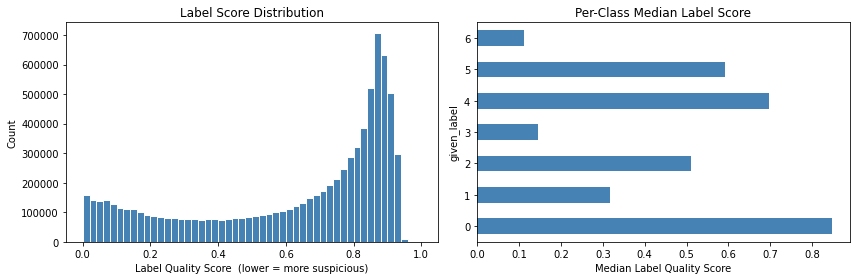

In [77]:
# Label Score Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(cleanlab_df["label_score"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Label Quality Score  (lower = more suspicious)")
axes[0].set_ylabel("Count")
axes[0].set_title("Label Score Distribution")

per_class = (
    cleanlab_df.groupby("given_label")["label_score"]
    .median()
)
per_class.plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_xlabel("Median Label Quality Score")
axes[1].set_title("Per-Class Median Label Score")

plt.tight_layout()
#plt.savefig("cleanlab_label_scores.png", dpi=120, bbox_inches="tight")
plt.show()